In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates


In [2]:
#v open the file and read it into a dataframe
df = pd.read_csv(
    "datasets/raw_data/INRIX_SPEED_AZ/processed/processed.csv",
    parse_dates=[0]       # parse first column as datetime
)

ref_df = pd.read_csv(
    "datasets/raw_data/INRIX_SPEED_AZ/processed/input.csv",
    header=None,          # since you saved without headers
    parse_dates=[0]       # parse first column as datetime
)

ref_df.columns = df.columns

# ref_df['datetime'] = pd.to_datetime(ref_df['datetime'])
ref_df = ref_df.set_index("timestamp").sort_index()

ref_df

,122385153,123094133,440907446,440907447,448798645,448798652,448801792,450124719,450136781,450178140,...,1226274258,1226274301,1226274364,1226276233,1226278116,1226278118,1226278270,1226278279,1226278747,1626426438
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-06-12 00:00:00,43.243415,14.671873,31.660357,43.629517,43.629517,39.768498,14.285771,12.355261,11.969160,11.969160,...,37.065784,10.424752,24.324421,42.085109,44.015619,43.243415,16.216281,19.305096,41.699007,44.015619
2025-06-12 00:05:00,42.857313,18.146790,31.660357,43.629517,43.629517,40.926803,14.285771,11.969160,10.038650,11.196956,...,36.679682,10.424752,18.146790,40.926803,44.401721,44.015619,16.216281,19.305096,41.699007,40.540702
2025-06-12 00:10:00,41.312905,16.988484,19.691198,42.085109,43.629517,39.382396,23.938319,11.196956,8.880344,11.583058,...,33.976969,18.146790,24.324421,39.768498,44.401721,43.629517,16.216281,22.780013,41.699007,40.540702
2025-06-12 00:15:00,40.154600,18.532892,23.938319,41.699007,44.015619,39.768498,43.243415,11.196956,13.899669,12.741363,...,33.204765,8.494242,20.077300,38.224090,45.173925,44.401721,14.285771,12.741363,40.926803,38.610192
2025-06-12 00:20:00,35.907479,15.444077,24.710523,42.857313,42.471211,40.154600,42.857313,15.444077,13.899669,11.196956,...,37.065784,9.652548,19.691198,40.926803,44.401721,44.015619,11.196956,11.969160,42.085109,37.837988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-14 23:35:00,44.015619,42.857313,42.857313,43.243415,44.787823,43.243415,44.401721,43.629517,42.857313,45.560027,...,41.699007,31.660357,41.699007,41.699007,44.401721,44.401721,43.243415,44.787823,42.857313,44.015619
2025-06-14 23:40:00,45.173925,44.401721,40.540702,43.629517,44.401721,43.243415,44.787823,43.243415,44.015619,44.401721,...,40.540702,39.768498,41.312905,41.699007,44.787823,45.173925,43.629517,45.173925,43.629517,42.085109
2025-06-14 23:45:00,44.787823,44.015619,40.154600,44.787823,44.787823,42.857313,44.787823,42.471211,42.085109,43.629517,...,43.243415,41.312905,42.085109,42.857313,44.787823,44.787823,43.629517,44.787823,43.243415,44.401721


In [3]:
output_files = [
    "out_dcrnn.csv",
    "out_gwnet.csv",
    "out_stid.csv",
]

aligned_outputs = {}

for output_file in output_files:
    df = pd.read_csv(output_file, header=None, parse_dates=[0])
    df.columns = ref_df.reset_index().columns
    df = df.set_index(df.columns[0])
    
    df_aligned = df.reindex(ref_df.index)
    
    # offset by 5 mins
    # df_aligned.index = df_aligned.index - pd.Timedelta(minutes=5)
    
    aligned_outputs[output_file] = df_aligned

ValueError: Length mismatch: Expected axis has 239 elements, new values have 164 elements

In [ ]:
def plot_sensor_predictions(
    sensor_id,
    start=None,
    end=None,
    n_points=None,
    interval=3,
):
    """
    Plot predictions vs ground truth for a sensor.

    Parameters
    ----------
    sensor_id : str
    start : str or datetime, optional
        Start date for subset
    end : str or datetime, optional
        End date for subset
    n_points : int, optional
        Plot only last N timestamps
    """

    # Ground truth
    dfs = [
        ref_df[[sensor_id]].rename(columns={sensor_id: "Ground Truth"})
    ]

    # Add model predictions
    for filename, df in aligned_outputs.items():
        model_name = filename.replace("out_", "").replace(".csv", "")
        dfs.append(
            df[[sensor_id]].rename(columns={sensor_id: model_name})
        )

    # Align and clean
    combined = pd.concat(dfs, axis=1, join="inner").dropna()

    # ---- Subset logic ----
    if start or end:
        combined = combined.loc[start:end]

    if n_points:
        combined = combined.tail(n_points)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))

    for col in combined.columns:
        ax.plot(combined.index, combined[col], label=col)

    ax.set_xlabel("Date")
    ax.set_ylabel("Speed (mph)")
    ax.set_title(f"Sensor {sensor_id}: Prediction vs Ground Truth")
    ax.legend()

    ax.xaxis.set_major_locator(mdates.HourLocator(interval=interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return combined

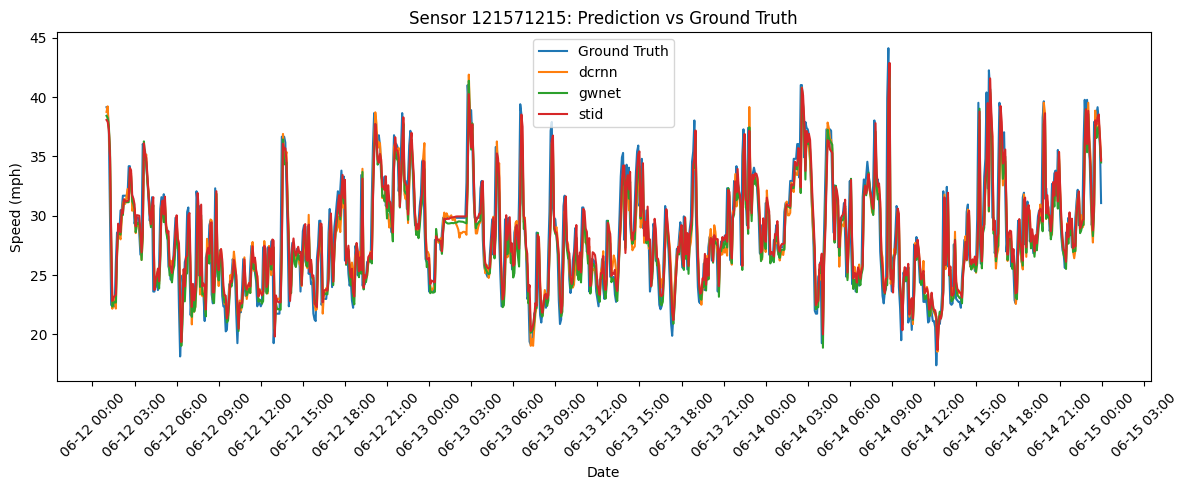

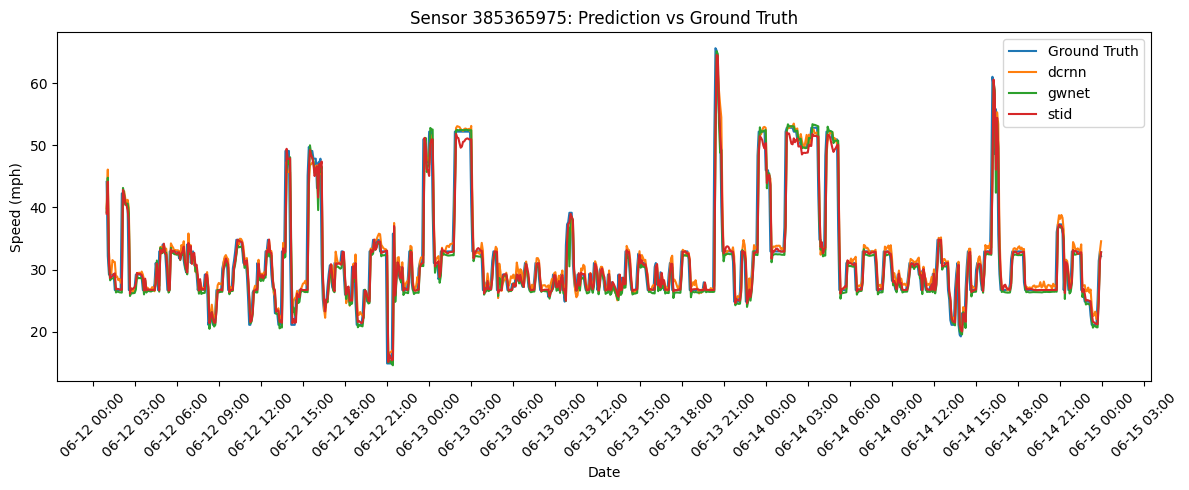

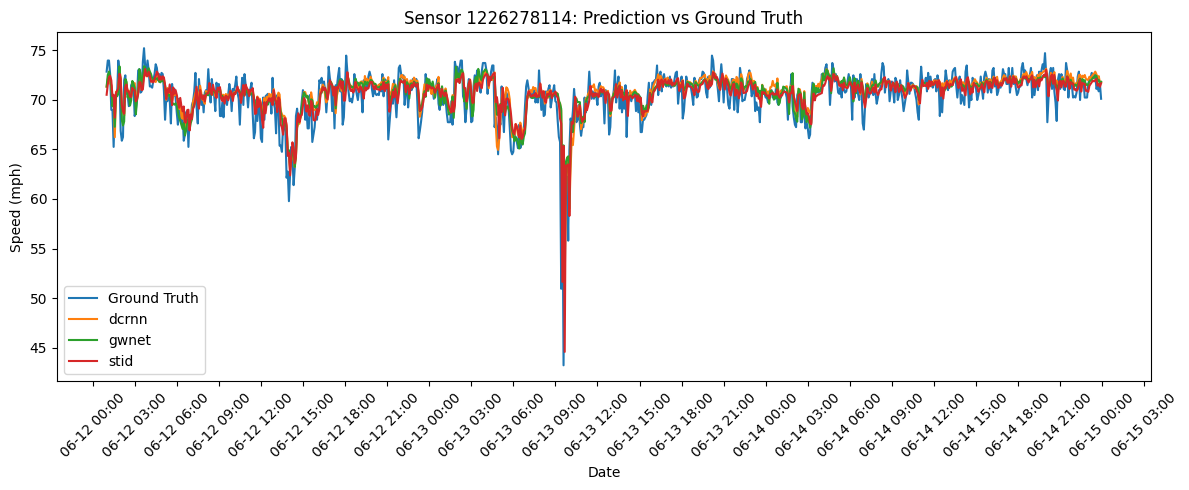

,Ground Truth,dcrnn,gwnet,stid
timestamp,,,,
2025-06-12 01:00:00,72.824681,71.300540,71.320120,70.494090
2025-06-12 01:05:00,73.943149,72.101390,72.497480,71.521360
2025-06-12 01:10:00,73.943149,71.906130,72.835190,72.264870
2025-06-12 01:15:00,72.576133,71.608600,72.183230,72.398895
2025-06-12 01:20:00,68.972181,71.480354,71.361046,71.947850
...,...,...,...,...
2025-06-14 23:35:00,71.084842,72.561830,72.396000,72.114330
2025-06-14 23:40:00,71.333391,72.237450,71.913030,71.416690
2025-06-14 23:45:00,70.836294,72.370390,72.000946,71.585860


In [ ]:
plot_sensor_predictions(sensor_id="121571215")
plot_sensor_predictions(sensor_id="385365975")
plot_sensor_predictions(sensor_id="1226278114")

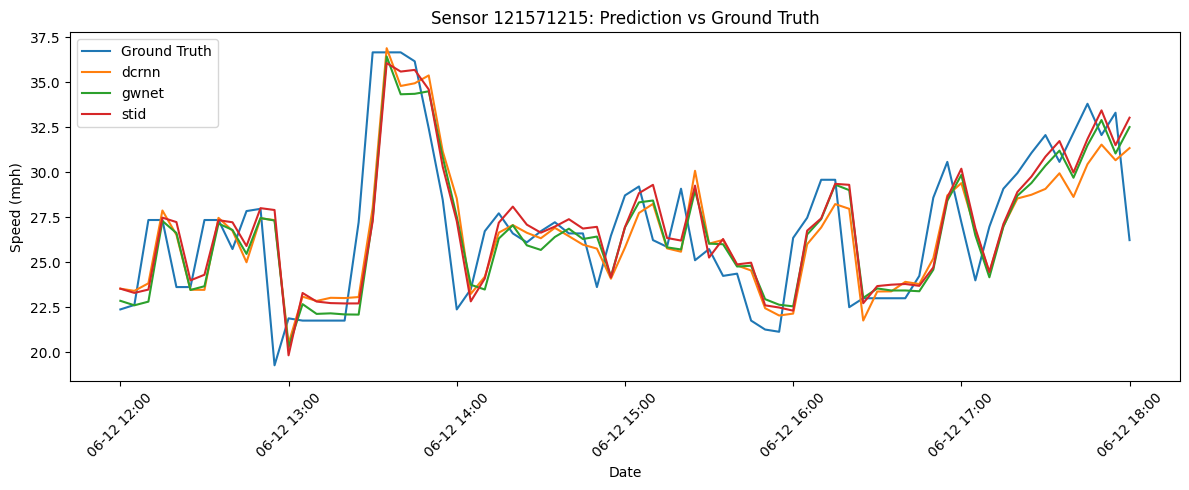

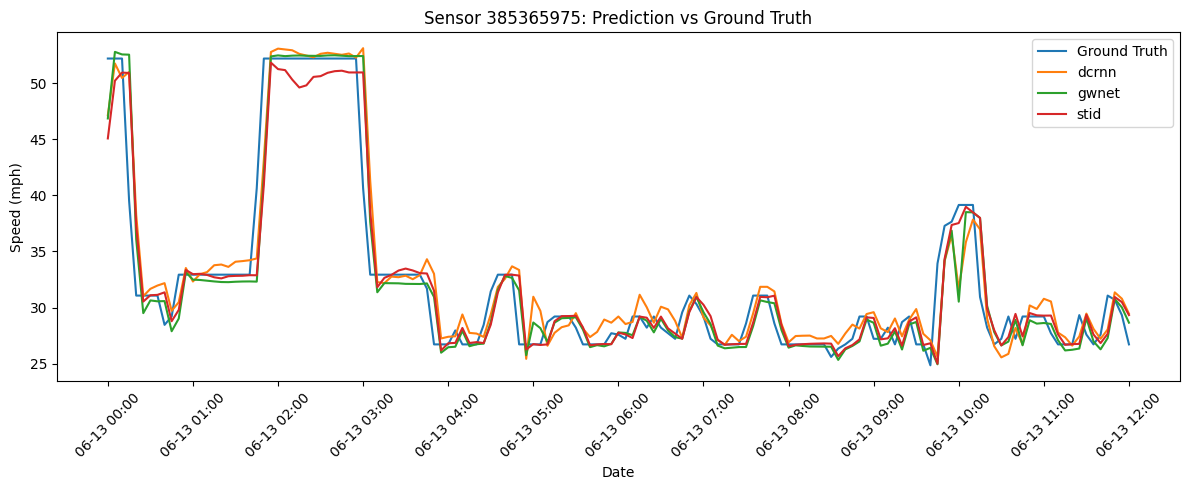

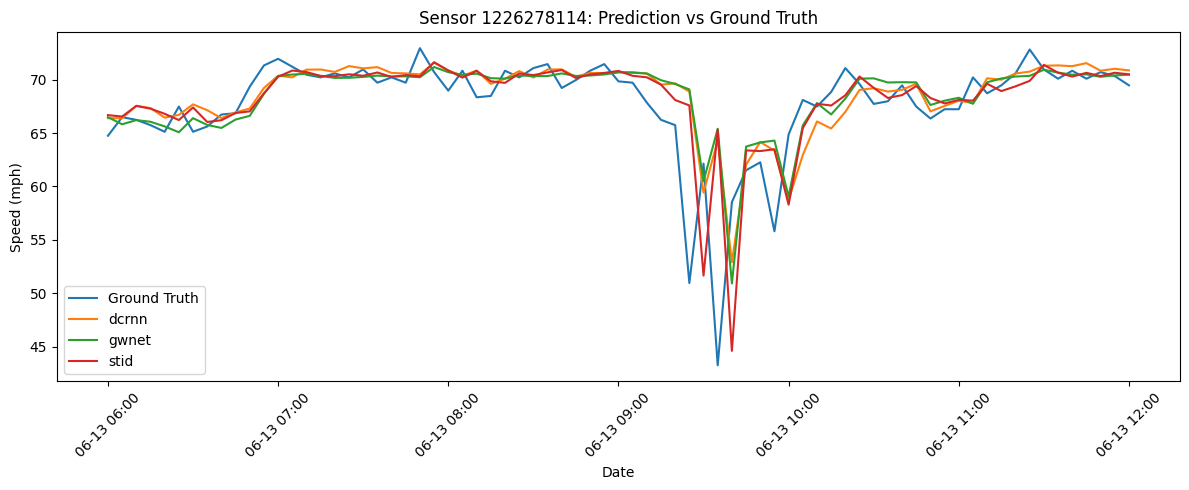

,Ground Truth,dcrnn,gwnet,stid
timestamp,,,,
2025-06-13 06:00:00,64.746858,66.392110,66.487560,66.677550
2025-06-13 06:05:00,66.486697,66.388885,65.822650,66.547104
2025-06-13 06:10:00,66.238149,67.553980,66.212480,67.542114
2025-06-13 06:15:00,65.741052,67.340340,66.058610,67.284060
2025-06-13 06:20:00,65.119681,66.444820,65.622930,66.802580
...,...,...,...,...
2025-06-13 11:40:00,70.836294,71.265076,70.463970,70.290810
2025-06-13 11:45:00,70.090649,71.550440,70.496574,70.639620
2025-06-13 11:50:00,70.712020,70.839660,70.269450,70.339355


In [ ]:
plot_sensor_predictions(
    "121571215",
    start="2025-06-12 12:00:00",
    end="2025-06-12 18:00:00",
    interval=1,
)
plot_sensor_predictions(
    "385365975",
    start="2025-06-13 0:00:00",
    end="2025-06-13 12:00:00",
    interval=1,
)
plot_sensor_predictions(
    "1226278114",
    start="2025-06-13 6:00:00",
    end="2025-06-13 12:00:00",
    interval=1,
)